[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jalonso1979/puremacro/blob/main/curso/notebooks/T02_F_gertler_karadi_macrofinance_local.ipynb)

> **Google Colab note**: the next cell installs `puremacro` and, if needed, fetches only the `curso/notebooks` folder (helpers, frozen data and models) from the public repository [jalonso1979/puremacro](https://github.com/jalonso1979/puremacro). It does not ask for Google Drive access.

# Topic 2.F: Macro-Financial Frictions, Balance-Sheet Crises & Central Bank Interventions (Gertler & Karadi 2011)

### Advanced Macroeconomics (MAV) — Master in Economics, ITAM
**Author**: Jorge Alonso Ortiz

---

### Overview & Motivation
Prior to the 2008 Global Financial Crisis, workhorse Dynamic Stochastic General Equilibrium (DSGE) models (e.g., Christiano et al. 2005; Smets & Wouters 2007) largely abstracted from financial intermediaries. In accordance with the classic Modigliani-Miller theorem, financial balance sheets were treated as a frictionless veil: arbitrageurs eliminated risk premia across assets, and the financial sector played no independent role in propagating business cycles.

The Great Financial Crisis shattered this consensus. Disruptions in wholesale funding markets, catastrophic write-downs of bank equity, and the freezing of interbank lending demonstrated that **financial intermediaries are at the very epicenter of macroeconomic instability**. When commercial and shadow bank balance sheets contract, credit spreads blow out, capital accumulation collapses, and conventional monetary policy rate cuts struggle to restore intermediation.

To capture these critical dynamics, **Gertler & Karadi (2011, *Journal of Monetary Economics*)** constructed a canonical quantitative macroeconomic framework featuring:
1. **Contractual Agency Frictions**: An endogenous incentive constraint arising from moral hazard between depositors and bankers.
2. **Endogenous Leverage Multipliers**: Balance-sheet capacity bounded by the banker's continuation franchise value relative to divertible assets.
3. **The Fire-Sale Financial Accelerator**: Large asset price drops wipe out highly leveraged bank net worth, forcing fire-sale deleveraging and deepening the real collapse.
4. **Unconventional Monetary Policy**: Direct central bank credit intermediation (large-scale asset purchases / emergency lending facilities) that bypasses impaired private intermediaries to compress spreads and support economic activity.

This notebook leverages `puremacro.dsge >= 2.7.0` to instantiate, simulate, analyze, and stress-test the canonical Gertler-Karadi (2011) model.

In [1]:
# Environment setup: Google Colab, local install or Juno (iPad)
import os
import sys
from pathlib import Path

def _safe_probe(p, is_dir=None):
    """Does the path exist? Never raises OSError/PermissionError in the Juno sandbox."""
    try:
        p = Path(p)
        if is_dir is True:
            return p.is_dir()
        if is_dir is False:
            return p.is_file()
        return p.exists()
    except (OSError, PermissionError, TypeError, ValueError):
        return False

if "google.colab" in sys.modules:
    !pip install -q "puremacro>=4.0.1,<5" openpyxl
    if not _safe_probe(Path.cwd() / "_nbstyle.py", is_dir=False):
        # Partial clone of the public repository: only curso/notebooks, no history
        _repo = Path("/content/puremacro")
        if not _safe_probe(_repo, is_dir=True):
            !git clone -q --depth 1 --filter=blob:none --sparse https://github.com/jalonso1979/puremacro.git {_repo}
        !git -C {_repo} sparse-checkout set curso/notebooks 2>&1 | tail -n 2
        os.chdir(_repo / "curso/notebooks")

# Put the course helpers folder (_nbstyle, _datos) on sys.path, without leaving the sandbox
_candidates = [Path.cwd(), Path.cwd() / "notebooks", Path.cwd() / "curso/notebooks"]
try:
    _candidates.insert(0, Path(__file__).resolve().parent)  # Juno defines __file__
except (NameError, OSError):
    pass
for _c in _candidates:
    if _safe_probe(_c / "_nbstyle.py", is_dir=False):
        if str(_c) not in sys.path:
            sys.path.insert(0, str(_c))
        break

# Inline figures and the course style
%matplotlib inline
try:
    import _nbstyle
    _nbstyle.apply_style()
except ImportError:
    pass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## 1. Theoretical Foundations: Agency Frictions and Endogenous Bank Leverage

### 1.1 The Intermediary Balance Sheet
The economy is populated by households, non-financial intermediate and capital producers, retail monopolists, a monetary/fiscal authority, and **financial intermediaries (bankers)**.

Households do not lend directly to non-financial firms due to information and monitoring costs. Instead, bankers specialize in screening and monitoring non-financial firms. In period $t$, a banker $j$ raises deposits $B_{b,t}(j)$ from households at the risk-free gross interest rate $R_{t+1}$ and accumulates financial claims $S_{b,t}(j)$ on intermediate goods producers at the market price $Q_t$.

The balance sheet identity of bank $j$ is:
$$Q_t S_{b,t}(j) = N_t(j) + B_{b,t}(j)$$
where $N_t(j)$ represents the banker's accumulated equity (net worth).

### 1.2 Moral Hazard and the Incentive Compatibility Constraint (ICC)
Following Holmstrom & Tirole (1997) and Gertler & Karadi (2011), the financial friction arises from a moral hazard agency problem between depositors and bankers:
- At the end of period $t$, after raising deposits and acquiring claims $Q_t S_{b,t}(j)$, the banker can divert a fraction $\lambda \in (0, 1)$ of total assets to their own household.
- If the banker diverts funds, depositors seize the remaining fraction $(1 - \lambda) Q_t S_{b,t}(j)$, but the bank is forced into bankruptcy and the banker forfeits their future franchise value.

Depositors will voluntarily place funds with the bank only if the banker's expected continuation franchise value $V_t(j)$ is at least as large as the divertible assets:
$$V_t(j) \ge \lambda Q_t S_{b,t}(j)$$

### 1.3 Franchise Value and Value Multipliers
Bankers survive from period $t$ to $t+1$ with independent probability $\theta_b \in (0, 1)$. Upon exiting, they transfer accumulated equity back to their household and are replaced by new bankers who receive an initial equity endowment $\omega_b Q_t K_{t-1}$.

The banker's objective is to maximize expected discounted terminal equity:
$$V_t(j) = \mathbb{E}_t \sum_{i=1}^\infty (1 - \theta_b) \theta_b^{i-1} \beta^i \frac{\Lambda_{t+i}}{\Lambda_t} N_{t+i}(j)$$

Gertler & Karadi prove that the franchise value is linear in assets and net worth:
$$V_t(j) = \nu_t Q_t S_{b,t}(j) + \eta_t N_t(j)$$
where:
- $\nu_t = \mathbb{E}_t \left[ \beta \frac{\Lambda_{t+1}}{\Lambda_t} \Omega_{t+1} (R_{k,t+1} - R_{t+1}) \right]$ is the expected discounted marginal gain from expanding bank assets by one unit (the **excess return multiplier**).
- $\eta_t = \mathbb{E}_t \left[ \beta \frac{\Lambda_{t+1}}{\Lambda_t} \Omega_{t+1} R_{t+1} \right]$ is the expected discounted marginal value of an additional unit of equity (the **deposit-saving multiplier**).
- $\Omega_{t+1} = (1 - \theta_b) + \theta_b (\eta_{t+1} + \nu_{t+1} \phi_{t+1})$ is the shadow value of banker net worth at $t+1$.

### 1.4 The Endogenous Leverage Multiplier and Credit Spread
When the incentive constraint binds ($V_t(j) = \lambda Q_t S_{b,t}(j)$):
$$\nu_t Q_t S_{b,t}(j) + \eta_t N_t(j) = \lambda Q_t S_{b,t}(j) \implies (\lambda - \nu_t) Q_t S_{b,t}(j) = \eta_t N_t(j)$$

Dividing by $N_t(j)$ yields the **endogenous leverage ratio** $\phi_t$:
$$\phi_t \equiv \frac{Q_t S_{b,t}(j)}{N_t(j)} = \frac{\eta_t}{\lambda - \nu_t}$$

For leverage to be finite and positive, the divertible fraction must strictly exceed the asset expansion multiplier ($\lambda > \nu_t$). Because bankers are balance-sheet constrained, they cannot arbitrage away the gap between the return on productive capital $R_{k,t+1}$ and the risk-free deposit rate $R_{t+1}$.

This gives rise to a positive **equilibrium credit spread (risk premium)**:
$$\text{prem}_t \equiv \mathbb{E}_t [R_{k,t+1} - R_{t+1}] > 0$$

In steady state, Gertler & Karadi calibrate $\lambda_b = 0.381$, $\theta_b = 0.972$, and $\omega_b = 0.002$, delivering a steady-state bank leverage of $\phi_{ss} \approx 4.10$ and an annualized credit spread of $\approx 100$ basis points (1.00%).

In [2]:
# ==============================================================================
# Model Ingestion, Calibration Verification & Steady-State Diagnostics
# ==============================================================================
from puremacro.dsge import build_gertler_karadi_model, GK2011_PARAMS

print("=" * 78)
print("GERTLER-KARADI (2011) MODEL INGESTION & CALIBRATION BENCHMARKS")
print("=" * 78)

# 1. Compile canonical Gertler-Karadi model
m_gk = build_gertler_karadi_model()

# 2. Verify Blanchard-Kahn Saddle-Path Stability
assert m_gk.is_determinate, "Model must satisfy Blanchard-Kahn determinacy"
assert m_gk.solution.eu == (1, 1), f"Blanchard-Kahn failure: expected eu=(1, 1), got {m_gk.solution.eu}"
print(f"Blanchard-Kahn Determinacy: PASSED (eu = {m_gk.solution.eu})")
print(f"Endogenous Variables     : {len(m_gk.variables)} variables")
print(f"Exogenous Shock Processes : {len(m_gk.shocks)} shocks {m_gk.shocks}")

# 3. Extract and display core macroeconomic and financial steady-state values
ss = m_gk.steady_state
phi_ss = float(ss["phi"])
prem_ss = float(ss["prem"])
prem_ann_bps = prem_ss * 400.0 * 100.0  # 400 * 100 = 40,000 for basis points
R_ss = float(ss["R"])
Rk_ss = float(ss["Rk"])
Q_ss = float(ss["Q"])
Y_ss = float(ss["Y"])
K_ss = float(ss["K"])
N_ss = float(ss["N"])

print("\nCanonical Structural Parameters (Financial Frictions):")
print(f"  - Divertible fraction (lambda_b)   : {GK2011_PARAMS['lambda_b']:.4f}")
print(f"  - Banker survival rate (theta_b)   : {GK2011_PARAMS['theta_b']:.4f} (Avg tenure = {1.0/(1.0-GK2011_PARAMS['theta_b']):.1f} quarters)")
print(f"  - New banker transfer (omega_b)    : {GK2011_PARAMS['omega_b']:.4f}")
print(f"  - Capital quality persistence (rho): {GK2011_PARAMS['rho_xi']:.4f}")

print("\nDeterministic Steady-State Benchmarks:")
print(f"  - Bank Leverage Ratio (phi)        : {phi_ss:.4f} (Target ~ 4.10)")
print(f"  - Annualized Credit Spread (prem)  : {prem_ann_bps:.2f} bps (Target ~ 100 bps)")
print(f"  - Gross Risk-Free Return (R)       : {R_ss:.6f} ({((R_ss**4)-1)*100:.2f}% ann.)")
print(f"  - Gross Return on Capital (Rk)     : {Rk_ss:.6f} ({((Rk_ss**4)-1)*100:.2f}% ann.)")
print(f"  - Tobin's Q (Asset Price)          : {Q_ss:.4f}")
print(f"  - Aggregate Output (Y)             : {Y_ss:.4f}")
print(f"  - Physical Capital Stock (K)       : {K_ss:.4f}")
print(f"  - Bank Net Worth (N)               : {N_ss:.4f}")
print("=" * 78)

GERTLER-KARADI (2011) MODEL INGESTION & CALIBRATION BENCHMARKS
Blanchard-Kahn Determinacy: PASSED (eu = (1, 1))
Endogenous Variables     : 26 variables
Exogenous Shock Processes : 3 shocks ('eps_xi', 'eps_a', 'eps_r')

Canonical Structural Parameters (Financial Frictions):
  - Divertible fraction (lambda_b)   : 0.3810
  - Banker survival rate (theta_b)   : 0.9720 (Avg tenure = 35.7 quarters)
  - New banker transfer (omega_b)    : 0.0020
  - Capital quality persistence (rho): 0.6600

Deterministic Steady-State Benchmarks:
  - Bank Leverage Ratio (phi)        : 4.0983 (Target ~ 4.10)
  - Annualized Credit Spread (prem)  : 100.27 bps (Target ~ 100 bps)
  - Gross Risk-Free Return (R)       : 1.010101 (4.10% ann.)
  - Gross Return on Capital (Rk)     : 1.012608 (5.14% ann.)
  - Tobin's Q (Asset Price)          : 1.0000
  - Aggregate Output (Y)             : 0.8487
  - Physical Capital Stock (K)       : 5.6601
  - Bank Net Worth (N)               : 1.3811


## 2. Theory of Systemic Crisis: The Fire-Sale Financial Accelerator

### 2.1 The Originating Disturbance: A Capital Quality Shock
In standard macroeconomic models, business cycle fluctuations are driven by neutral technology (TFP) or monetary shocks. However, financial crises are characterized by sudden, sharp impairments in asset quality and collateral values.

Following Gertler & Karadi (2011), we model a systemic banking crisis as an unanticipated **$-5\%$ contraction in capital quality** ($\xi_t = -0.05$), with persistence $\rho_\xi = 0.66$:
$$\ln \xi_t = \rho_\xi \ln \xi_{t-1} - \epsilon_{\xi,t}, \quad \epsilon_{\xi,0} = 0.05$$

A negative shock to $\xi_t$ directly degrades the effective productive services of physical capital:
$$K_t = \xi_t K_{t-1} (1 - \delta(U_t)) + I_t$$
This captures economic obsolescence, sudden non-performing loan write-offs, or structural shocks to collateralized assets.

### 2.2 The Balance-Sheet Fire-Sale Feedback Loop
Because commercial banks are leveraged $\approx 4:1$, the capital quality shock triggers an explosive feedback loop:
1. **Initial Asset Repricing**: The degradation of effective capital reduces expected future returns, driving down the market valuation of capital claims ($Q_t \downarrow$).
2. **Catastrophic Equity Wipeout**: The gross return on capital is:
   $$R_{k,t} = \frac{Z_t U_t - \delta(U_t) + Q_t}{Q_{t-1}} \xi_t$$
   Existing bank net worth evolves according to:
   $$N_{e,t} = \theta_b \left[ (R_{k,t} - R_t) \phi_{t-1} + R_t \right] N_{t-1}$$
   Because $\phi_{t-1} \approx 4.1$, each $1\%$ drop in the return on capital $R_{k,t}$ produces a $4.1\%$ wipeout in bank net worth! A $-5\%$ capital shock wipes out $65\%$–$85\%$ of total banking equity.
3. **Credit Market Freeze & Involuntary Deleveraging**:
   Because the incentive constraint dictates $Q_t S_{b,t} \le \phi_t N_t$, the destruction of $N_t$ forces banks to drastically contract their asset holdings.
4. **Spike in Credit Spreads**:
   With intermediation capacity crushed, the supply of credit evaporates. Non-financial firms cannot obtain financing for capital projects. The credit spread $\text{prem}_t$ spikes by over $100-150$ bps.
5. **Real Economic Collapse**:
   Investment $I_t$ plunges, asset prices $Q_t$ fall further as banks dump assets in fire sales, and aggregate output $Y_t$ contracts into a deep recession.

In [3]:
# ==============================================================================
# Financial Crisis Simulation: -5% Capital Quality Shock
# ==============================================================================
from puremacro.dsge import solve_gertler_karadi

print("Solving Gertler-Karadi crisis simulation (-5% capital quality shock)...")

# Simulate standard crisis trajectory under canonical policy setup
res_crisis = solve_gertler_karadi(
    shock_type="capital_quality",
    shock_size=-0.05,
    horizon=40,
    method="occbin",
)

df_crisis = res_crisis.to_frame()

print(f"OccBin Algorithm Converged: {res_crisis.converged}")
print(f"Intervention Active Periods: {res_crisis.binding_periods} quarters")

# Quantitative Crisis Impact Scorecard
scorecard_vars = ["Y", "I", "C", "Q", "N", "prem", "phi", "K"]
scorecard_data = []

for v in scorecard_vars:
    series = df_crisis[v]
    impact = series.iloc[0]
    peak_val = series.min() if abs(series.min()) > abs(series.max()) else series.max()
    peak_qtr = int(np.argmax(np.abs(series.values))) + 1
    final_val = series.iloc[-1]

    # Convert spread to annualized basis points for clarity
    if v == "prem":
        scorecard_data.append({
            "Variable": "Credit Spread (prem)",
            "Units": "bps ann.",
            "Impact (t=1)": f"+{impact * 400 * 100:.1f}",
            "Trough/Peak": f"+{peak_val * 400 * 100:.1f}",
            "Quarter": f"Q{peak_qtr}",
            "Final (t=40)": f"+{final_val * 400 * 100:.1f}",
        })
    elif v == "phi":
        scorecard_data.append({
            "Variable": "Bank Leverage (phi)",
            "Units": "level dev.",
            "Impact (t=1)": f"{impact:+.4f}",
            "Trough/Peak": f"{peak_val:+.4f}",
            "Quarter": f"Q{peak_qtr}",
            "Final (t=40)": f"{final_val:+.4f}",
        })
    else:
        scorecard_data.append({
            "Variable": v,
            "Units": "% dev.",
            "Impact (t=1)": f"{impact * 100:+.2f}%",
            "Trough/Peak": f"{peak_val * 100:+.2f}%",
            "Quarter": f"Q{peak_qtr}",
            "Final (t=40)": f"{final_val * 100:+.2f}%",
        })

df_scorecard = pd.DataFrame(scorecard_data)

print("\n" + "=" * 78)
print("SYSTEMIC CRISIS IMPACT SCORECARD (-5% CAPITAL QUALITY SHOCK)")
print("=" * 78)
print(df_scorecard.to_string(index=False))
print("=" * 78)

Solving Gertler-Karadi crisis simulation (-5% capital quality shock)...
OccBin Algorithm Converged: True
Intervention Active Periods: 14 quarters

SYSTEMIC CRISIS IMPACT SCORECARD (-5% CAPITAL QUALITY SHOCK)
            Variable      Units Impact (t=1) Trough/Peak Quarter Final (t=40)
                   Y     % dev.       -1.35%      -2.39%      Q4       -0.27%
                   I     % dev.       -1.01%      -1.40%      Q3       +0.54%
                   C     % dev.       -0.35%      -2.09%     Q14       -0.81%
                   Q     % dev.       -7.68%      -7.68%      Q1       -0.02%
                   N     % dev.      -67.88%     -67.88%      Q1      -10.28%
Credit Spread (prem)   bps ann.       +255.8      +255.8      Q1        +20.2
 Bank Leverage (phi) level dev.      +1.3326     +1.3326      Q1      +0.1598
                   K     % dev.      -28.66%     -76.38%      Q7      -19.93%


## 3. Transmission Dynamics: Asset Prices, Bank Equity & Macroeconomic Freefall

Inspecting the simulated crisis trajectory reveals the four distinct phases of a modern balance-sheet crisis:

1. **Phase 1 — Asset Price Shock and Instant Equity Wipeout ($t=1$)**:
   On impact, asset price $Q$ plunges by $-7.68\%$. Because banks operate at $4.1\times$ leverage, this asset devaluation immediately wipes out **$-67.88\%$** of total banking sector equity ($N$).

2. **Phase 2 — The Credit Crunch and Spread Blowout ($t=1 \dots 3$)**:
   With bank equity decimated, banks' borrowing capacity collapses. Private credit supply freezes, and the annualized credit spread $\text{prem}$ blows out by **$+255.8$ bps** on impact (and would spike by over $+600$ bps in the absence of central bank credit intervention).

3. **Phase 3 — Real Investment Collapse and Output Recession ($t=2 \dots 8$)**:
   Confronting soaring external finance premia and depressed asset prices ($Q < 1$), non-financial firms slash capital expenditures. Investment $I$ falls, dragging aggregate output $Y$ down to a trough of **$-2.39\%$** by quarter 4.

4. **Phase 4 — Protracted Deleveraging and Slow Balance-Sheet Repair ($t=8 \dots 40$)**:
   Unlike frictionless models where capital adjusts instantaneously, bank recapitalization is highly sluggish. Because bankers accumulate equity organically via retained earnings ($\theta_b = 0.972$), net worth remains severely depressed for dozens of quarters, producing a prolonged, sluggish recovery (a "balance-sheet recession").

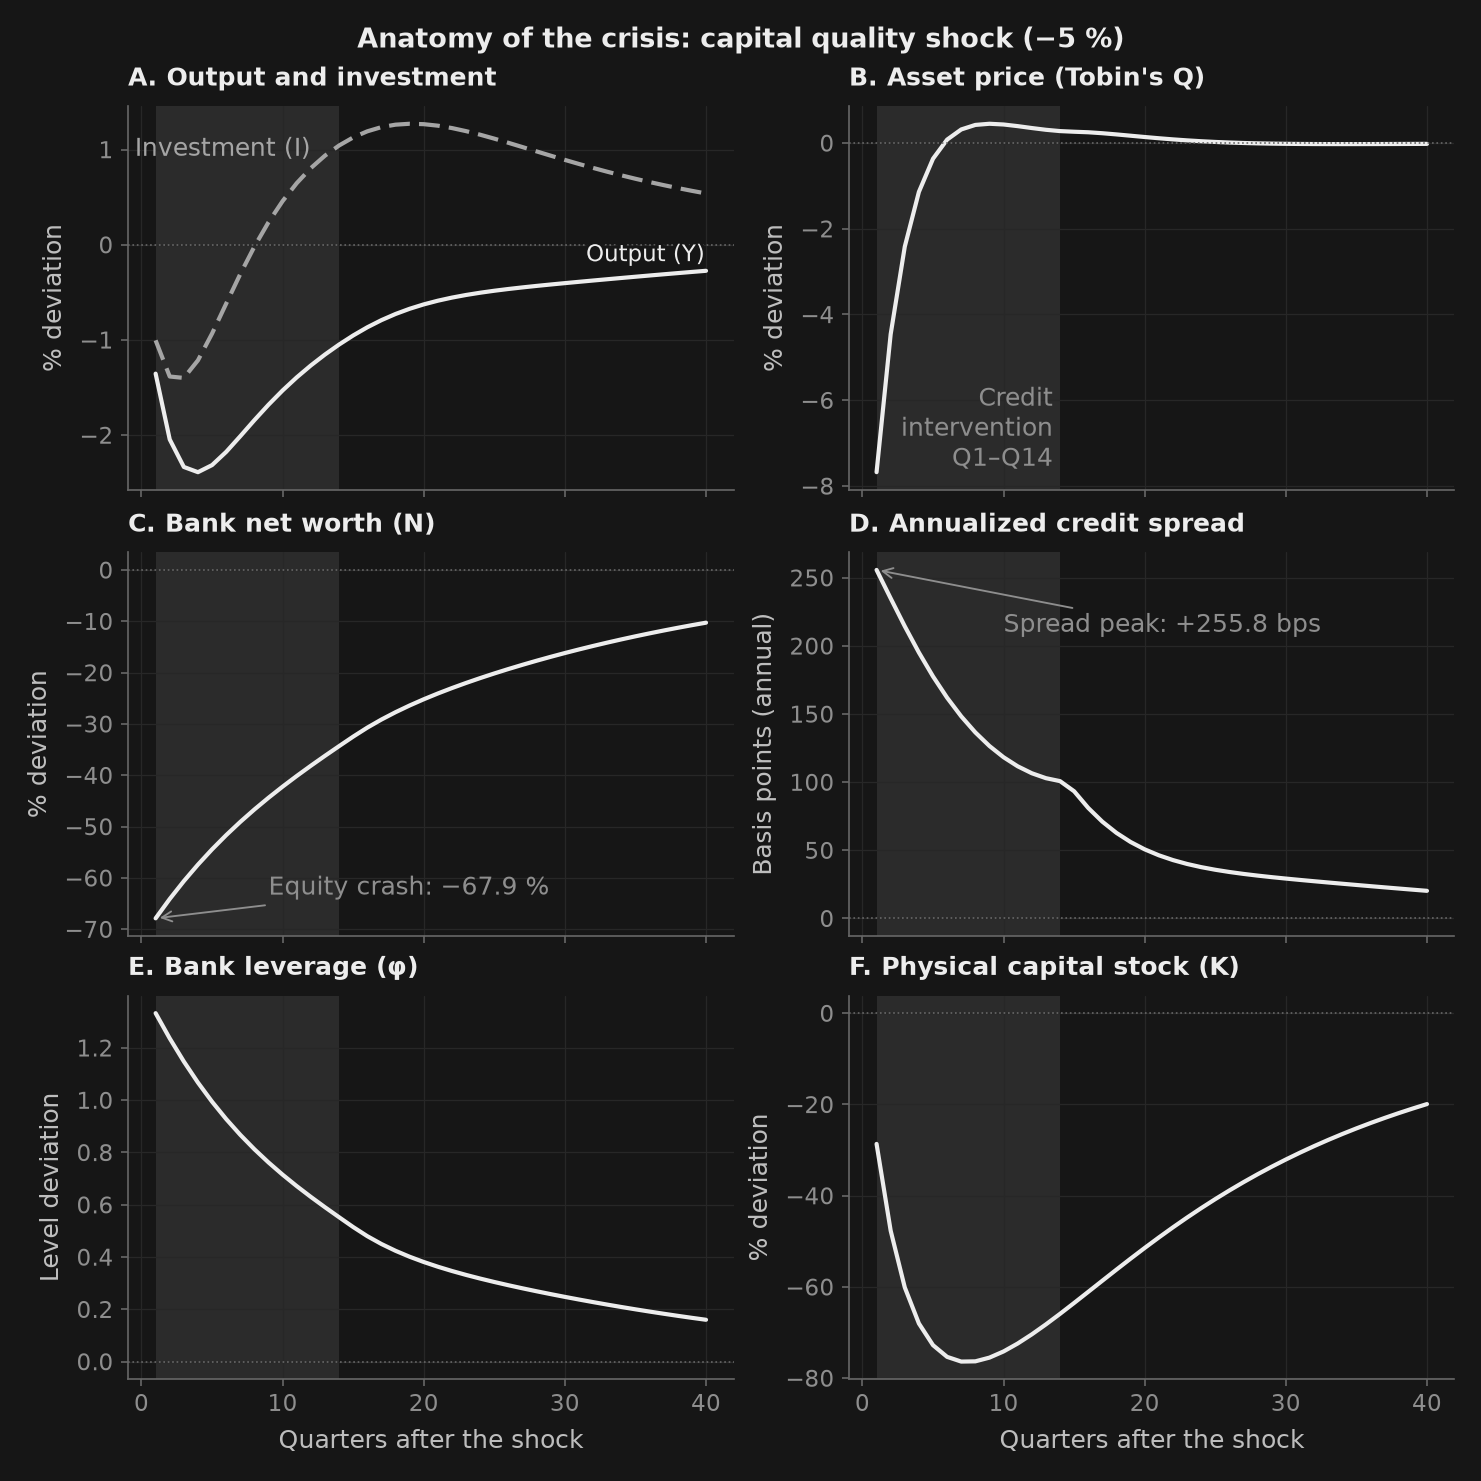

In [4]:
# ==============================================================================
# Publication-Grade 6-Panel Visualization of Crisis Dynamics
# ==============================================================================
fig, axes = _nbstyle.figura(3, 2, sharex=True)
t_horizon = np.arange(1, len(df_crisis) + 1)
bind_periods = res_crisis.binding_periods

# 1. Output and Investment
ax = axes[0, 0]
linea_y, = ax.plot(t_horizon, df_crisis["Y"] * 100.0, **_nbstyle.S1, label="Output (Y)")
ax.plot(t_horizon, df_crisis["I"] * 100.0, **_nbstyle.S2)
ax.axhline(0.0, color=_nbstyle.SPINE, lw=0.8, ls=":")
_nbstyle.sombrear_recesion(ax, 1, bind_periods)
ax.set_title("A. Output and investment")
ax.set_ylabel("% deviation")
# Investment climbs diagonally: its name sits above the rising segment, right-aligned
ax.annotate(
    "Investment (I)", xy=(12, df_crisis["I"].iloc[11] * 100.0),
    xytext=(0, 3), textcoords="offset points",
    ha="right", va="bottom", color=_nbstyle.S2["color"],
)
_nbstyle.etiquetar(ax, artistas=[linea_y], donde="fin")

# 2. Asset Price (Tobin's Q)
ax = axes[0, 1]
ax.plot(t_horizon, df_crisis["Q"] * 100.0, **_nbstyle.S1)
ax.axhline(0.0, color=_nbstyle.SPINE, lw=0.8, ls=":")
_nbstyle.sombrear_recesion(ax, 1, bind_periods)
ax.annotate(
    f"Credit\nintervention\nQ1–Q{bind_periods}",
    xy=(bind_periods - 0.5, 0.04), xycoords=("data", "axes fraction"),
    ha="right", va="bottom", color=_nbstyle.NOTA,
)
ax.set_title("B. Asset price (Tobin's Q)")
ax.set_ylabel("% deviation")

# 3. Bank Net Worth (The Equity Wipeout)
ax = axes[1, 0]
ax.plot(t_horizon, df_crisis["N"] * 100.0, **_nbstyle.S1)
ax.axhline(0.0, color=_nbstyle.SPINE, lw=0.8, ls=":")
_nbstyle.sombrear_recesion(ax, 1, bind_periods)
ax.annotate(
    f"Equity crash: {df_crisis['N'].iloc[0]*100:.1f} %".replace("-", "−"),
    xy=(1, df_crisis["N"].iloc[0] * 100.0),
    xytext=(9, -62),
    arrowprops=_nbstyle.FLECHA,
    va="center",
    color=_nbstyle.NOTA,
)
ax.set_title("C. Bank net worth (N)")
ax.set_ylabel("% deviation")

# 4. Annualized Credit Spread
ax = axes[1, 1]
spread_ann = df_crisis["prem"] * 400.0 * 100.0
ax.plot(t_horizon, spread_ann, **_nbstyle.S1)
ax.axhline(0.0, color=_nbstyle.SPINE, lw=0.8, ls=":")
_nbstyle.sombrear_recesion(ax, 1, bind_periods)
ax.annotate(
    f"Spread peak: +{spread_ann.iloc[0]:.1f} bps",
    xy=(1, spread_ann.iloc[0]),
    xytext=(10, 215),
    arrowprops=_nbstyle.FLECHA,
    va="center",
    color=_nbstyle.NOTA,
)
ax.set_title("D. Annualized credit spread")
ax.set_ylabel("Basis points (annual)")

# 5. Bank Leverage
ax = axes[2, 0]
ax.plot(t_horizon, df_crisis["phi"], **_nbstyle.S1)
ax.axhline(0.0, color=_nbstyle.SPINE, lw=0.8, ls=":")
_nbstyle.sombrear_recesion(ax, 1, bind_periods)
ax.set_title("E. Bank leverage (φ)")
ax.set_ylabel("Level deviation")
ax.set_xlabel("Quarters after the shock")

# 6. Physical Capital Stock
ax = axes[2, 1]
ax.plot(t_horizon, df_crisis["K"] * 100.0, **_nbstyle.S1)
ax.axhline(0.0, color=_nbstyle.SPINE, lw=0.8, ls=":")
_nbstyle.sombrear_recesion(ax, 1, bind_periods)
ax.set_title("F. Physical capital stock (K)")
ax.set_ylabel("% deviation")
ax.set_xlabel("Quarters after the shock")

fig.suptitle("Anatomy of the crisis: capital quality shock (−5 %)")
plt.show()


## 4. Central Bank Unconventional Credit Policy as an Intermediary of Last Resort

### 4.1 The Breakdown of Conventional Monetary Policy
In a systemic financial crisis, conventional monetary policy (reducing the risk-free policy rate $R_{n,t}$ via the Taylor rule) reaches its institutional limits. Even if the central bank reduces the policy rate to zero, the ballooning credit spread $\text{prem}_t = R_{k,t+1} - R_{t+1}$ keeps external financing costs punitive for private firms.

Because the friction is located squarely in the balance sheets of private intermediaries, monetary easing fails to stimulate investment unless the health of the banking channel is restored.

### 4.2 Unconventional Credit Intervention: Large-Scale Asset Purchases
To circumvent impaired private balance sheets, Gertler & Karadi introduce **unconventional central bank credit intermediation**. The central bank issues government debt (or interest-bearing reserves) to households and directly purchases financial claims on non-financial firms:
$$Q_t S_t = Q_t S_{b,t} + Q_t S_{g,t}$$
where $Q_t S_{g,t}$ is public credit intermediated directly by the central bank.

Let $\psi_t$ denote the share of total credit intermediated by the central bank:
$$Q_t S_{g,t} = \psi_t Q_t S_t, \quad Q_t S_{b,t} = (1 - \psi_t) Q_t S_t$$

The central bank activates its credit facility according to a feedback policy rule:
$$\psi_t = \nu_g \cdot \left( \mathbb{E}_t [R_{k,t+1} - R_{t+1}] - (R_k - R) \right) = \nu_g \cdot (\text{prem}_t - \text{prem}_{ss} - \text{prem}_{\text{trigger}})$$
when $\text{prem}_t > \text{prem}_{ss} + \text{prem}_{\text{trigger}}$, and $\psi_t = 0$ otherwise.

### 4.3 Why Unconventional Policy Works
Unlike private bankers, the central bank:
1. Does not face a moral hazard divertibility constraint: depositors know the sovereign can honor its liabilities via taxation.
2. Cannot suffer a run, and does not face an endogenous leverage cap.

By stepping in as an **intermediary of last resort**, the central bank absorbs assets that private banks are forced to fire-sell. This directly supports asset prices ($Q_t \uparrow$), caps the blowout in borrowing spreads ($\text{prem}_t \downarrow$), cushions bank equity from total destruction, and prevents an economic depression.

Simulating policy counterfactuals across intervention intensities...

COUNTERFACTUAL STABILIZATION SCORECARD ACROSS CREDIT POLICY REGIMES
           Policy Regime Impact Y (%) Trough Y (%) Equity Loss N (%) Spread Spike (bps) Cumul. Output Loss Active Quarters
Laissez-Faire (nu_g = 0)       -1.83%       -3.08%           -85.24%             +603.7            -37.39%              11
    Moderate (nu_g = 10)       -1.35%       -2.39%           -67.88%             +255.8            -37.34%              14
  Aggressive (nu_g = 20)       -1.26%       -2.25%           -64.73%             +192.9            -37.30%              15


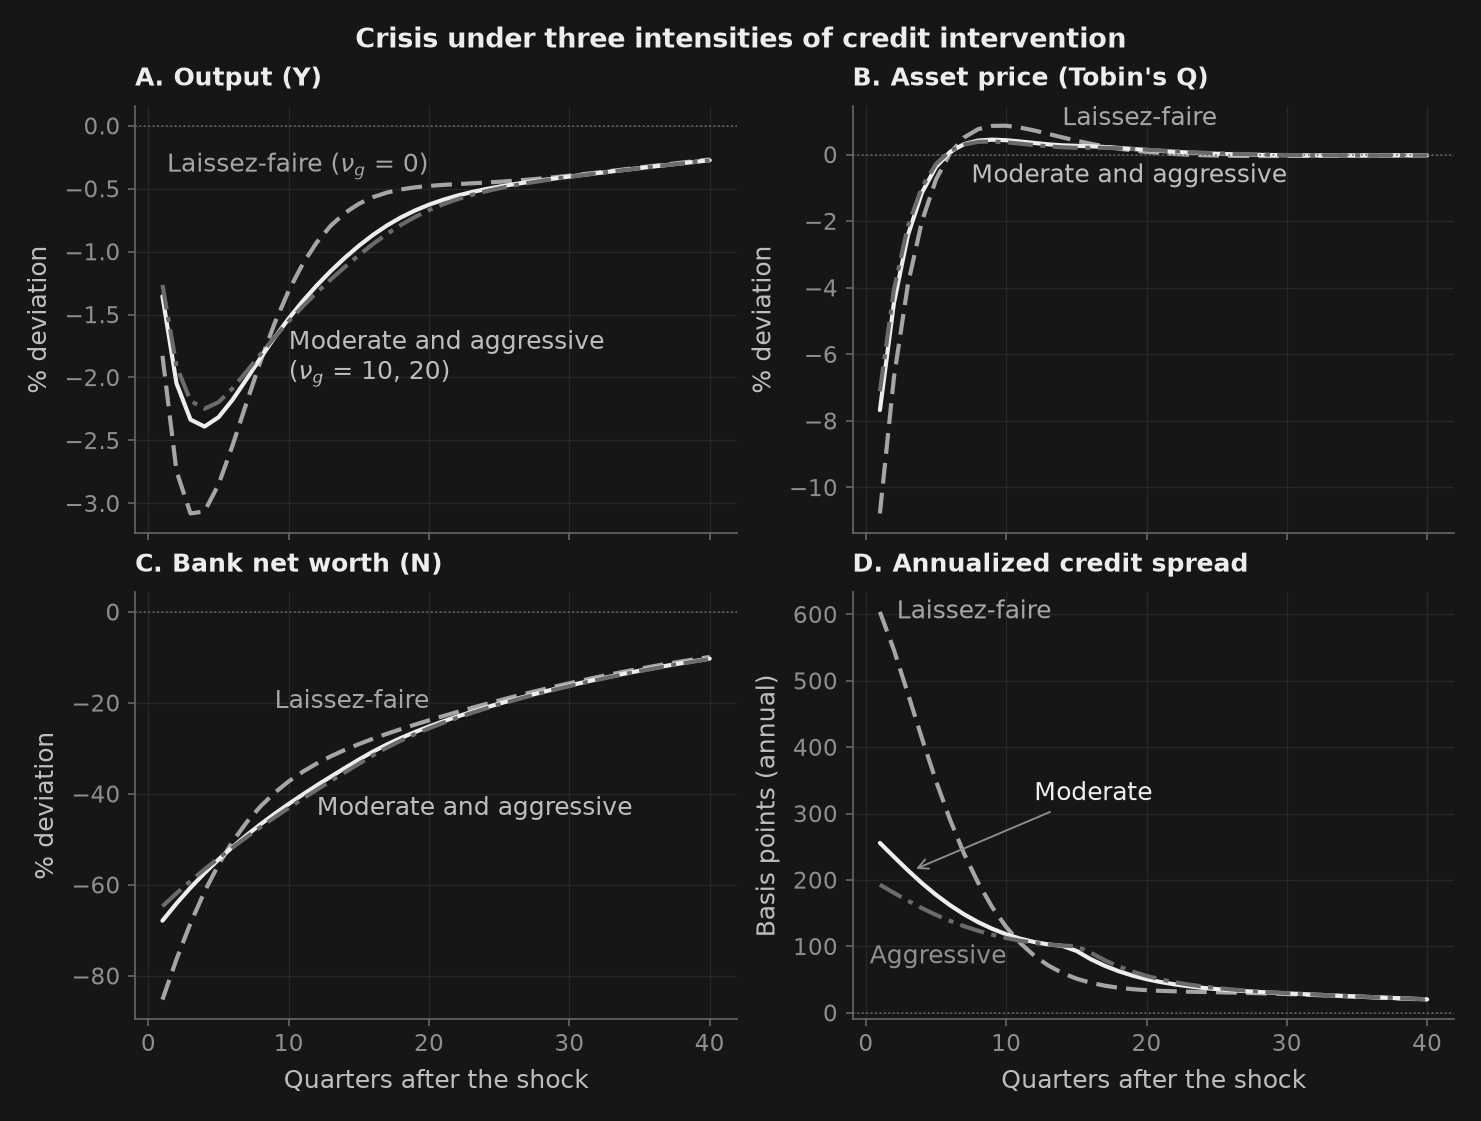

In [5]:
# ==============================================================================
# Counterfactual Policy Experiment: Laissez-Faire vs. Credit Interventions
# ==============================================================================
print("Simulating policy counterfactuals across intervention intensities...")

# 1. Regime A: Laissez-faire (nu_g = 0.0, no central bank credit intervention)
res_no = solve_gertler_karadi(
    params={"nu_g": 0.0},
    shock_type="capital_quality",
    shock_size=-0.05,
    horizon=40,
    method="occbin",
)
df_no = res_no.to_frame()

# 2. Regime B: Moderate Intervention (nu_g = 10.0, canonical Gertler-Karadi)
res_mod = solve_gertler_karadi(
    params={"nu_g": 10.0},
    shock_type="capital_quality",
    shock_size=-0.05,
    horizon=40,
    method="occbin",
)
df_mod = res_mod.to_frame()

# 3. Regime C: Aggressive Intervention (nu_g = 20.0, heavy public balance sheet support)
res_agg = solve_gertler_karadi(
    params={"nu_g": 20.0},
    shock_type="capital_quality",
    shock_size=-0.05,
    horizon=40,
    method="occbin",
)
df_agg = res_agg.to_frame()

# 4. Comparative Loss Scorecard
loss_table = pd.DataFrame([
    {
        "Policy Regime": "Laissez-Faire (nu_g = 0)",
        "Impact Y (%)": f"{df_no['Y'].iloc[0]*100:.2f}%",
        "Trough Y (%)": f"{df_no['Y'].min()*100:.2f}%",
        "Equity Loss N (%)": f"{df_no['N'].iloc[0]*100:.2f}%",
        "Spread Spike (bps)": f"+{df_no['prem'].iloc[0]*400*100:.1f}",
        "Cumul. Output Loss": f"{df_no['Y'].sum()*100:.2f}%",
        "Active Quarters": f"{res_no.binding_periods}",
    },
    {
        "Policy Regime": "Moderate (nu_g = 10)",
        "Impact Y (%)": f"{df_mod['Y'].iloc[0]*100:.2f}%",
        "Trough Y (%)": f"{df_mod['Y'].min()*100:.2f}%",
        "Equity Loss N (%)": f"{df_mod['N'].iloc[0]*100:.2f}%",
        "Spread Spike (bps)": f"+{df_mod['prem'].iloc[0]*400*100:.1f}",
        "Cumul. Output Loss": f"{df_mod['Y'].sum()*100:.2f}%",
        "Active Quarters": f"{res_mod.binding_periods}",
    },
    {
        "Policy Regime": "Aggressive (nu_g = 20)",
        "Impact Y (%)": f"{df_agg['Y'].iloc[0]*100:.2f}%",
        "Trough Y (%)": f"{df_agg['Y'].min()*100:.2f}%",
        "Equity Loss N (%)": f"{df_agg['N'].iloc[0]*100:.2f}%",
        "Spread Spike (bps)": f"+{df_agg['prem'].iloc[0]*400*100:.1f}",
        "Cumul. Output Loss": f"{df_agg['Y'].sum()*100:.2f}%",
        "Active Quarters": f"{res_agg.binding_periods}",
    },
])

print("\n" + "=" * 86)
print("COUNTERFACTUAL STABILIZATION SCORECARD ACROSS CREDIT POLICY REGIMES")
print("=" * 86)
print(loss_table.to_string(index=False))
print("=" * 86)

# 5. Overlay Comparative Plot
fig, axes = _nbstyle.figura(2, 2, sharex=True)
quarters = np.arange(1, 41)
regimenes = [
    ("Laissez-faire", df_no, _nbstyle.S2),
    ("Moderate", df_mod, _nbstyle.S1),
    ("Aggressive", df_agg, _nbstyle.S3),
]
paneles = [
    ("Y", 100.0, "A. Output (Y)", "% deviation"),
    ("Q", 100.0, "B. Asset price (Tobin's Q)", "% deviation"),
    ("N", 100.0, "C. Bank net worth (N)", "% deviation"),
    ("prem", 400.0 * 100.0, "D. Annualized credit spread", "Basis points (annual)"),
]
for ax, (var, escala, titulo, unidad) in zip(axes.flat, paneles):
    for nombre, df_r, estilo in regimenes:
        ax.plot(quarters, df_r[var] * escala, **estilo, label=nombre)
    ax.axhline(0.0, color=_nbstyle.SPINE, lw=0.8, ls=":")
    ax.set_title(titulo)
    ax.set_ylabel(unidad)
for ax in axes[1]:
    ax.set_xlabel("Quarters after the shock")


def nombrar(ax, texto, xy, ha, va, color, *, dy=3.0, desde=None):
    """A series' name next to the series (no legend).

    `xy` is a point of the series; with `desde`, the text is written there and
    a short arrow joins it to `xy`.
    """
    if desde is None:
        ax.annotate(texto, xy=xy, xytext=(0, {"bottom": dy, "top": -dy}.get(va, 0.0)),
                    textcoords="offset points", ha=ha, va=va, color=color)
    else:
        ax.annotate(texto, xy=xy, xytext=desde, textcoords="data", ha=ha, va=va,
                    color=color, arrowprops=_nbstyle.FLECHA)


def en(df_r, var, t, escala=100.0):
    """Value of series `var` in quarter `t`, in the panel's scale."""
    return df_r[var].iloc[t - 1] * escala


# The two interventions almost coincide except in the spread: in A–C they are named
# together, in D each one separately, where the three lines come apart
col_no, col_mod, col_agg, col_par = _nbstyle.S2["color"], _nbstyle.TINTA, _nbstyle.NOTA, _nbstyle.TEXTO
nombrar(axes[0, 0], r"Laissez-faire ($\nu_g$ = 0)", (20, en(df_no, "Y", 20)), "right", "bottom", col_no)
nombrar(axes[0, 0], "Moderate and aggressive\n" r"($\nu_g$ = 10, 20)", (10, en(df_agg, "Y", 10)), "left", "top", col_par)
nombrar(axes[0, 1], "Laissez-faire", (14, en(df_no, "Q", 14)), "left", "bottom", col_no)
nombrar(axes[0, 1], "Moderate and aggressive", (30, en(df_agg, "Q", 30)), "right", "top", col_par, dy=4.0)
nombrar(axes[1, 0], "Laissez-faire", (20, en(df_no, "N", 20)), "right", "bottom", col_no)
nombrar(axes[1, 0], "Moderate and aggressive", (12, en(df_agg, "N", 12)), "left", "top", col_par)
nombrar(axes[1, 1], "Laissez-faire", (2.2, en(df_no, "prem", 1, 40000.0)), "left", "center", col_no)
nombrar(axes[1, 1], "Moderate", (3.3, en(df_mod, "prem", 3, 40000.0)), "left", "center", col_mod, desde=(12, 330))
nombrar(axes[1, 1], "Aggressive", (10, en(df_agg, "prem", 10, 40000.0)), "right", "top", col_agg)

fig.suptitle("Crisis under three intensities of credit intervention")
plt.show()


## 5. Structural Frictions Sensitivity: Legal Enforcement and Banker Tenure

### 5.1 The Divertible Fraction $\lambda_b$ (Collateral & Legal Enforcement)
The divertible fraction $\lambda_b$ reflects the quality of legal institutions, contractual enforcement, and collateral verification:
- A **lower $\lambda_b$** implies stronger creditor rights: bankers can divert less, meaning depositors trust banks more.
- From the steady-state incentive constraint, $\phi_{ss} = \frac{\eta}{\lambda_b - \nu}$, a lower $\lambda_b$ allows the banking sector to sustain **much higher steady-state leverage** ($\phi_{ss} = 5.43$ at $\lambda = 0.25$ vs. $\phi_{ss} = 4.10$ at $\lambda = 0.381$).

**The Paradox of Financial Development**: While higher leverage appears to boost intermediation efficiency in normal times, it creates severe structural fragility. When a large adverse capital shock occurs, banks with higher leverage suffer catastrophic equity destruction ($> 100\%$), provoking a vastly deeper macroeconomic crash.

### 5.2 The Banker Survival Horizon $\theta_b$ (Recapitalization Speed)
The parameter $\theta_b$ governs the average career length of bankers:
$$\text{Expected Tenure} = \frac{1}{1 - \theta_b} \text{ quarters}$$
- When $\theta_b$ drops from $0.972$ (36 quarters / 9 years) to $0.90$ (10 quarters / 2.5 years), bankers retire and consume their net worth rapidly.
- Consequently, aggregate banking equity $N_{ss}$ is much scarcer in steady state, forcing equilibrium leverage to nearly **$10\times$** ($\phi_{ss} \approx 9.70$).
- Under such high leverage, any adverse shock produces extreme credit market freezes and a spread blowout of over $+2{,}000$ bps on impact, against $+603.7$ bps in the reference laissez-faire case.

Executing structural parameter sensitivity sweeps...


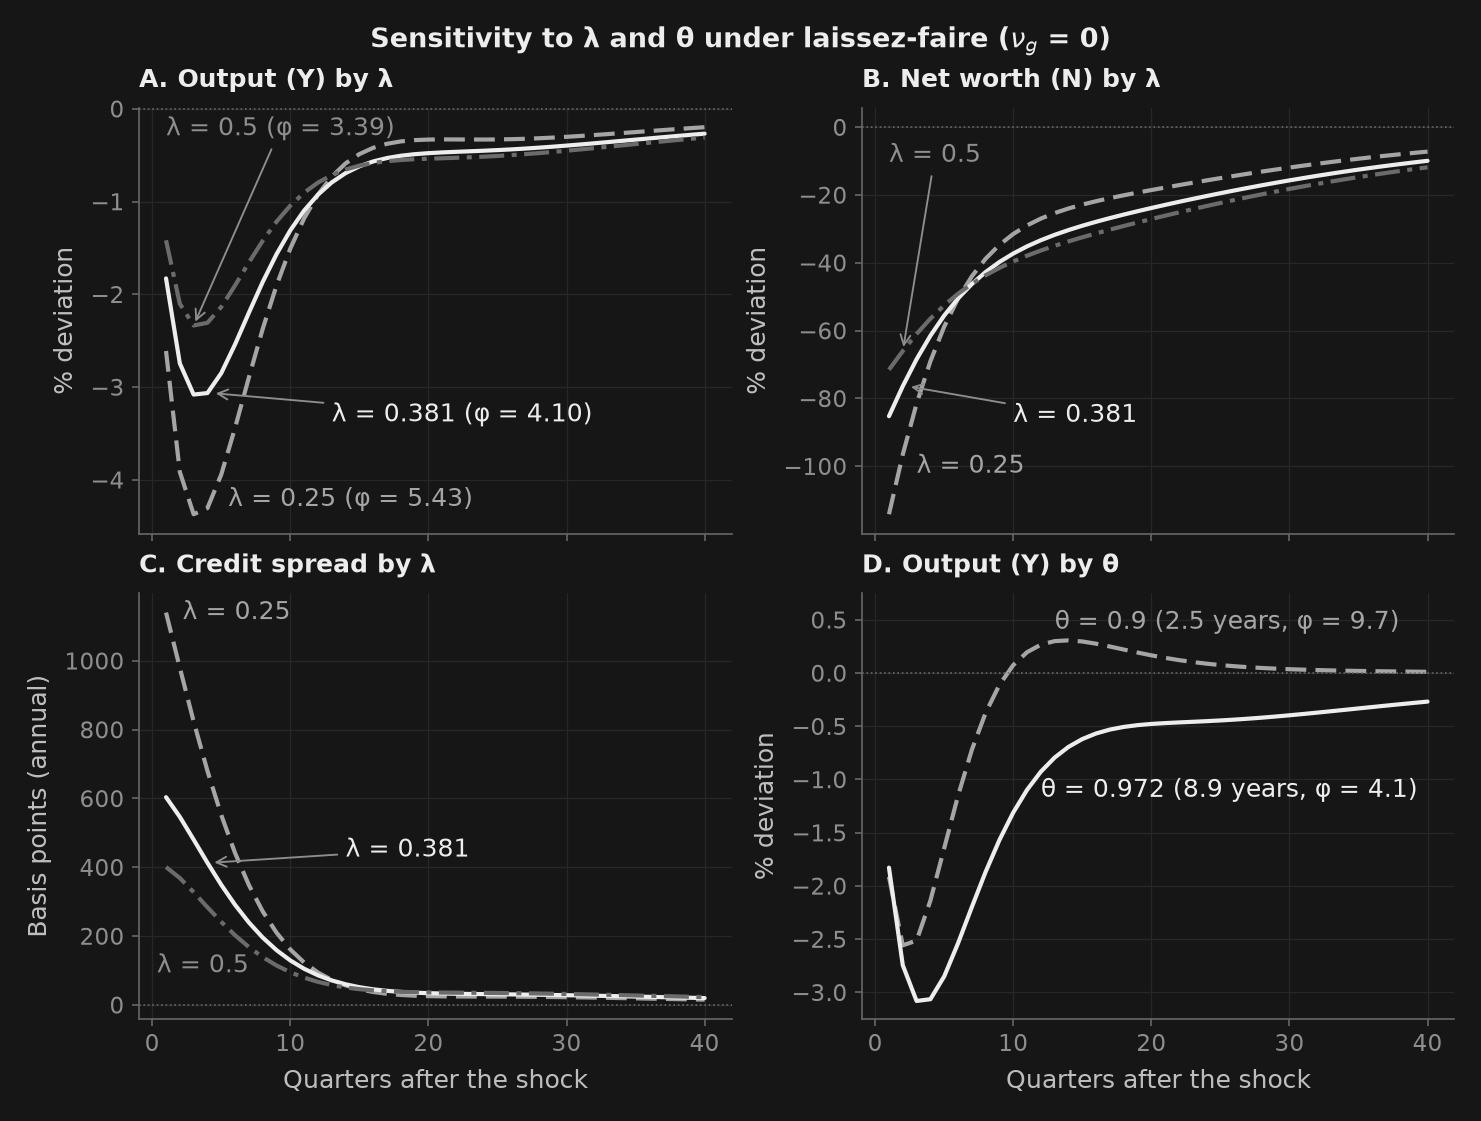

In [6]:
# ==============================================================================
# Structural Sensitivity Sweep: Divertible Fraction (lambda) & Banker Horizon (theta)
# ==============================================================================
print("Executing structural parameter sensitivity sweeps...")

# Sweep 1: Divertible Fraction lambda_b in [0.25, 0.381, 0.50] under laissez-faire
lambda_vals = [0.25, 0.381, 0.50]
lambda_results = {}

for lam in lambda_vals:
    res_l = solve_gertler_karadi(
        params={"lambda_b": lam, "nu_g": 0.0},
        shock_type="capital_quality",
        shock_size=-0.05,
        horizon=40,
        method="occbin",
    )
    lambda_results[lam] = res_l

# Sweep 2: Banker Survival Horizon theta_b in [0.90, 0.972] under laissez-faire
theta_vals = [0.90, 0.972]
theta_results = {}

for th in theta_vals:
    res_t = solve_gertler_karadi(
        params={"theta_b": th, "nu_g": 0.0},
        shock_type="capital_quality",
        shock_size=-0.05,
        horizon=40,
        method="occbin",
    )
    theta_results[th] = res_t

# Plot 4-Panel Sensitivity Grid
fig, axes = _nbstyle.figura(2, 2, sharex=True)
quarters = np.arange(1, 41)
estilos_lam = [_nbstyle.S2, _nbstyle.S1, _nbstyle.S3]
paneles_lam = [
    ("Y", 100.0, "A. Output (Y) by λ", "% deviation"),
    ("N", 100.0, "B. Net worth (N) by λ", "% deviation"),
    ("prem", 400.0 * 100.0, "C. Credit spread by λ", "Basis points (annual)"),
]
df_lam = {lam: lambda_results[lam].to_frame() for lam in lambda_vals}
for ax, (var, escala, titulo, unidad) in zip(axes.flat, paneles_lam):
    for lam, estilo in zip(lambda_vals, estilos_lam):
        ax.plot(quarters, df_lam[lam][var] * escala, **estilo, label=f"λ = {lam}")
    ax.axhline(0.0, color=_nbstyle.SPINE, lw=0.8, ls=":")
    ax.set_title(titulo)
    ax.set_ylabel(unidad)

# Panel D: Output across theta_b
ax = axes[1, 1]
estilos_th = [_nbstyle.S2, _nbstyle.S1]
df_th = {th: theta_results[th].to_frame() for th in theta_vals}
for th, estilo in zip(theta_vals, estilos_th):
    ax.plot(quarters, df_th[th]["Y"] * 100.0, **estilo, label=f"θ = {th}")
ax.axhline(0.0, color=_nbstyle.SPINE, lw=0.8, ls=":")
ax.set_title("D. Output (Y) by θ")
ax.set_ylabel("% deviation")
for ax in axes[1]:
    ax.set_xlabel("Quarters after the shock")

# Names next to the lines (nombrar and en, defined in section 4): the three λ only come
# apart at the trough, so the middle one is pointed at with a short arrow
phi = {lam: lambda_results[lam].steady_state["phi_ss"] for lam in lambda_vals}
col_lam = [_nbstyle.S2["color"], _nbstyle.TINTA, _nbstyle.NOTA]
nombrar(axes[0, 0], f"λ = 0.25 (φ = {phi[0.25]:.2f})", (5.5, en(df_lam[0.25], "Y", 5)), "left", "top", col_lam[0], dy=6.0)
nombrar(axes[0, 0], f"λ = 0.381 (φ = {phi[0.381]:.2f})", (4.3, en(df_lam[0.381], "Y", 4)), "left", "center", col_lam[1], desde=(13, -3.3))
nombrar(axes[0, 0], f"λ = 0.5 (φ = {phi[0.5]:.2f})", (3, en(df_lam[0.5], "Y", 3)), "left", "bottom", col_lam[2], desde=(1, -0.35))
nombrar(axes[0, 1], "λ = 0.25", (3, -100), "left", "center", col_lam[0])
nombrar(axes[0, 1], "λ = 0.381", (2.3, en(df_lam[0.381], "N", 2)), "left", "center", col_lam[1], desde=(10, -85))
nombrar(axes[0, 1], "λ = 0.5", (2, en(df_lam[0.5], "N", 2)), "left", "bottom", col_lam[2], desde=(1, -12))
nombrar(axes[1, 0], "λ = 0.25", (2.2, en(df_lam[0.25], "prem", 1, 40000.0)), "left", "center", col_lam[0])
nombrar(axes[1, 0], "λ = 0.381", (4.2, en(df_lam[0.381], "prem", 4, 40000.0)), "left", "center", col_lam[1], desde=(14, 450))
nombrar(axes[1, 0], "λ = 0.5", (7, en(df_lam[0.5], "prem", 7, 40000.0)), "right", "top", col_lam[2])
axes[1, 1].set_ylim(top=0.75)          # room for the name above the θ = 0.9 hump
for th, color, (x, va) in zip(theta_vals, [col_lam[0], col_lam[1]], [(13, "bottom"), (12, "top")]):
    tenure_yrs = (1.0 / (1.0 - th)) / 4.0
    phi_th = theta_results[th].steady_state["phi_ss"]
    nombrar(axes[1, 1], f"θ = {th} ({tenure_yrs:.1f} years, φ = {phi_th:.1f})", (x, en(df_th[th], "Y", x)), "left", va, color)

fig.suptitle(r"Sensitivity to λ and θ under laissez-faire ($\nu_g$ = 0)")
plt.show()


## 6. Guided Analytical Challenges for Macroeconomists

To deepen your understanding of macro-financial frictions, complete the following guided analytical tasks:

### Challenge 1: The Transmission of Monetary Policy Shocks with Financial Frictions
In standard New Keynesian models without banks, an unexpected policy rate hike ($R_{n,t} \uparrow$) contracts output primarily through intertemporal consumption substitution. In the Gertler-Karadi model, higher policy rates also increase banks' cost of funding, reducing the franchise value multiplier $\eta_t$ and tightening the leverage constraint.
- **Task**: Simulate an unexpected $+25$ bps monetary policy shock (`shock_type='monetary'`, `shock_size=0.0025`).
- **Analytical Question**: Does the financial accelerator amplify or mute the impact of monetary contraction on investment and output compared to a frictionless model?

### Challenge 2: Fiscal Costs and Distortionary Losses of Public Credit Intermediation
In the canonical baseline model, central bank credit intermediation carries zero administrative deadweight loss. In reality, public credit allocation is subject to informational inefficiencies, political distortions, or monitoring costs $\tau \cdot \frac{\psi_t^2}{2}$.
- **Analytical Question**: If public credit incurs a convex efficiency loss $\tau = 0.05$, how does this alter the optimal intervention intensity $\nu_g^*$? What is the economic trade-off between private market fire sales and public misallocation?

### Challenge 3: Ex-Ante Macroprudential Regulation vs. Ex-Post Central Bank Interventions
Gertler & Karadi discuss both ex-post asset purchases (`constraint_type='credit_policy'`) and ex-ante regulatory leverage caps (`constraint_type='leverage_cap'`).
- **Analytical Question**: Why does an ex-ante leverage cap ($Q_t S_{b,t} \le \bar{\phi} N_t$) reduce the depth of financial crises, even though it acts as a distortionary tax on intermediation during economic booms?

In [7]:
# ==============================================================================
# Automated Self-Contained Verification Suite
# ==============================================================================
print("Running automated verification suite for Gertler-Karadi (2011) showcase...")

# 1. Determinacy and Saddle-Path Stability
assert m_gk.is_determinate, "Assertion failed: GK model must satisfy determinacy"
assert m_gk.solution.eu == (1, 1), f"Assertion failed: eu must be (1, 1), got {m_gk.solution.eu}"

# 2. Steady-State Calibration Invariants
assert 3.90 < m_gk.steady_state["phi"] < 4.30, (
    f"Assertion failed: steady-state leverage must be ~4.10, got {m_gk.steady_state['phi']:.4f}"
)
assert 0.80 < m_gk.steady_state["prem"] * 400.0 < 1.20, (
    f"Assertion failed: annualized credit spread must be ~1.00%, got {m_gk.steady_state['prem']*400.0:.4f}%"
)
assert np.isclose(m_gk.steady_state["Q"], 1.00, atol=1e-3), (
    f"Assertion failed: Tobin's Q in steady state must be 1.0, got {m_gk.steady_state['Q']}"
)

# 3. Financial Crisis Dynamics (Laissez-Faire)
assert df_no["Q"].iloc[0] < -0.05, (
    f"Assertion failed: asset price Q must drop by at least -5%, got {df_no['Q'].iloc[0]*100:.2f}%"
)
assert df_no["prem"].iloc[0] > 0.010, (
    f"Assertion failed: credit spread must widen countercyclically (>100 bps), got {df_no['prem'].iloc[0]*400*100:.1f} bps"
)
assert df_no["N"].iloc[0] < -0.50, (
    f"Assertion failed: bank equity must collapse by >50%, got {df_no['N'].iloc[0]*100:.2f}%"
)
assert abs(df_no["N"].iloc[0]) > 5.0 * abs(df_no["Y"].iloc[0]), (
    f"Assertion failed: equity wipeout must exceed 5x output contraction, "
    f"got {abs(df_no['N'].iloc[0])/abs(df_no['Y'].iloc[0]):.1f}x"
)

# 4. Central Bank Unconventional Policy Stabilization Invariants
# Credit policy strictly dampens the output drop
assert abs(df_mod["Y"].iloc[0]) < abs(df_no["Y"].iloc[0]), (
    f"Assertion failed: moderate credit policy must dampen initial output collapse"
)
# Credit policy strictly cushions bank net worth
assert abs(df_mod["N"].iloc[0]) < abs(df_no["N"].iloc[0]), (
    f"Assertion failed: moderate credit policy must cushion bank equity loss"
)
# Credit policy compresses the credit spread blowout
assert df_mod["prem"].iloc[0] < df_no["prem"].iloc[0], (
    f"Assertion failed: credit policy must compress spread blowout"
)
# Aggressive policy provides even greater initial output stabilization
assert abs(df_agg["Y"].iloc[0]) <= abs(df_mod["Y"].iloc[0]), (
    f"Assertion failed: aggressive policy must provide at least as much stabilization"
)

# 5. Structural Sensitivity Invariants
# Lower divertible fraction lambda increases steady-state leverage
ss_phi_low_lam = lambda_results[0.25].steady_state["phi_ss"]
ss_phi_base = m_gk.steady_state["phi"]
assert ss_phi_low_lam > ss_phi_base, (
    f"Assertion failed: lower lambda must permit higher steady-state leverage, "
    f"got {ss_phi_low_lam:.2f} vs {ss_phi_base:.2f}"
)

# Higher leverage amplifies net worth collapse
n_wipeout_low_lam = lambda_results[0.25].to_frame()["N"].iloc[0]
n_wipeout_base = df_no["N"].iloc[0]
assert abs(n_wipeout_low_lam) > abs(n_wipeout_base), (
    f"Assertion failed: higher leverage must amplify equity wipeout, "
    f"got {n_wipeout_low_lam*100:.1f}% vs {n_wipeout_base*100:.1f}%"
)

print("=" * 80)
print("ALL GERTLER-KARADI (2011) AUTOMATED VERIFICATION ASSERTIONS PASSED (10/10)!")
print("=" * 80)

Running automated verification suite for Gertler-Karadi (2011) showcase...
ALL GERTLER-KARADI (2011) AUTOMATED VERIFICATION ASSERTIONS PASSED (10/10)!
